# 09-Event Streaming with Apache Kafka

In Lesson 08, we tapped into the Write-Ahead Log (WAL) of our database using Debezium CDC. We successfully captured real-time row mutations ($\Delta D$) without querying the application tables.

But a critical architectural question remains: **Where do these CDC events go?**
If a source database generates 50,000 events per second, and our downstream data warehouse can only ingest 5,000 events per second, the pipeline will physically bottleneck, overflow the Python RAM, and catastrophically crash.

To bridge systems with mismatched throughputs, we must engineer a **Distributed Event Streaming Fabric**. We need a mathematically perfect shock-absorber that can hold unbounded streams of data in chronological order until the downstream consumers are ready to process them. The undisputed global standard for this is **Apache Kafka**.

Let's set up our environment to engineer the physics of the distributed commit log.

In [1]:
# Required installations: pip install confluent-kafka matplotlib seaborn
import time
import json
from confluent_kafka import Producer, Consumer, KafkaError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Kafka Streaming Environment Initialized.")

✅ Systems Architecture & Kafka Streaming Environment Initialized.


*(Note: Executing the Kafka network connections requires a live Kafka Broker running on `localhost:9092` via Docker. The code below is exact production-grade syntax).*

# 1. The Mathematics of the Distributed Commit Log

Kafka is not a database, and it is not a traditional message queue (like RabbitMQ). Kafka is a **Distributed Append-Only Commit Log**.

### The Topic and the Partition Matrix

In Kafka, data is organized into **Topics** ($\mathcal{T}$). A Topic is physically sharded across multiple server nodes (Brokers) into a set of **Partitions** $\mathcal{P} = \{p_0, p_1, \dots, p_N\}$.

A Partition $p_i$ is a strictly ordered, immutable sequence of records. Every time a new event is appended to a partition, it is assigned a mathematically monotonic integer called an **Offset** ($\mathcal{O}$).


$$p_i = [ (\mathcal{O}_0, \text{msg}_0), (\mathcal{O}_1, \text{msg}_1), \dots, (\mathcal{O}_n, \text{msg}_n) ]$$

### The Hashing Physics of Data Locality

When a Producer sends a message to a Topic, how does Kafka decide which partition it goes to?
If you send events without a key, Kafka uses Round-Robin distribution, which destroys the chronological order of related events.

To guarantee that all CDC updates for a specific `user_id` are processed in the exact order they occurred, the Producer specifies a **Message Key** ($k$). Kafka applies a deterministic hashing function to route the message to a specific partition:


$$p_{target} = \text{hash}(k) \pmod N$$

Because the hash function is deterministic, all updates for `user_id=42` will physically land in $p_2$. Since partitions are strictly ordered, chronological integrity is mathematically guaranteed.

# 2. Architecting the Producer Engine

Let's build a highly reliable Kafka Producer. We will simulate a continuous stream of IoT sensor readings or CDC database events. We will implement asynchronous delivery callbacks to verify that the mathematical offset was successfully registered on the remote Broker cluster.

In [2]:
# --- 📤 STEP 1: The Kafka Producer Engine ---

# 1. Configure the Physical Connection to the Broker Cluster
producer_config = {
    'bootstrap.servers': 'localhost:9092', # The cluster entrypoint
    'client.id': 'enterprise_sensor_producer',
    'acks': 'all',                         # Mathematics of Reliability: Wait for all replica brokers to acknowledge
    'compression.type': 'snappy'           # Compress payloads to save network bandwidth
}

# Initialize the librdkafka C-engine wrapper
producer = Producer(producer_config)
topic_name = "enterprise.sensor.telemetry"

# 2. Define the Asynchronous Network Callback
def delivery_report(err, msg):
    """
    Called asynchronously when a message is physically acknowledged by the Kafka Broker.
    """
    if err is not None:
        print(f"❌ [NETWORK FAILURE] Message delivery failed: {err}")
    else:
        # Retrieve the exact Partition and Offset coordinate generated by the Broker
        print(f"   ✅ [ACK] Record delivered to Partition [{msg.partition()}] at Offset $\\mathcal{{O}}_{{{msg.offset()}}}")

# 3. Stream Events into the Cluster
print(f"--- 🚀 Initiating High-Throughput Stream to Topic: '{topic_name}' ---")

# Simulating 3 rapid events being produced
sensor_events = [
    {"sensor_id": "SN-01", "temp": 72.4, "status": "OK"},
    {"sensor_id": "SN-02", "temp": 104.2, "status": "WARNING"},
    {"sensor_id": "SN-01", "temp": 72.8, "status": "OK"}
]

for event in sensor_events:
    # We MUST extract the sensor_id to act as the Mathematical Key
    message_key = event["sensor_id"]
    message_payload = json.dumps(event)
    
    print(f"📤 [PRODUCE] Emitting Key: '{message_key}' -> Payload: {message_payload}")
    
    # Asynchronously append the message to the local memory buffer
    producer.produce(
        topic=topic_name,
        key=message_key.encode('utf-8'), # The Hash Key
        value=message_payload.encode('utf-8'),
        callback=delivery_report
    )
    
    # Trigger the underlying C-library to handle the network transmission
    producer.poll(0)

# Flush the physical network buffer to ensure all messages leave RAM before shutdown
print("   ⏳ Flushing network buffers...")
producer.flush(timeout=5.0)
print("--- 🏁 Producer Stream Complete ---")

print("\n--- 💡 Engineering Insight ---")
print("Notice how we passed `sensor_id` as the message key. 'SN-01' will be mathematically hashed. Both the first and third events will be routed to the exact same partition (e.g., Partition 0). 'SN-02' will hash to a different integer and land in a different partition (e.g., Partition 1). This guarantees that downstream analytics will process SN-01's temperature changes in perfect chronological order, avoiding race conditions.")

--- 🚀 Initiating High-Throughput Stream to Topic: 'enterprise.sensor.telemetry' ---
📤 [PRODUCE] Emitting Key: 'SN-01' -> Payload: {"sensor_id": "SN-01", "temp": 72.4, "status": "OK"}
📤 [PRODUCE] Emitting Key: 'SN-02' -> Payload: {"sensor_id": "SN-02", "temp": 104.2, "status": "WARNING"}
📤 [PRODUCE] Emitting Key: 'SN-01' -> Payload: {"sensor_id": "SN-01", "temp": 72.8, "status": "OK"}
   ⏳ Flushing network buffers...
   ✅ [ACK] Record delivered to Partition [0] at Offset $\mathcal{O}_{0}
   ✅ [ACK] Record delivered to Partition [0] at Offset $\mathcal{O}_{1}
   ✅ [ACK] Record delivered to Partition [0] at Offset $\mathcal{O}_{2}
--- 🏁 Producer Stream Complete ---

--- 💡 Engineering Insight ---
Notice how we passed `sensor_id` as the message key. 'SN-01' will be mathematically hashed. Both the first and third events will be routed to the exact same partition (e.g., Partition 0). 'SN-02' will hash to a different integer and land in a different partition (e.g., Partition 1). This guarantee

# 3. Architecting the Consumer Engine

Now, we must read the data out of the shock-absorber. In Kafka, Consumers operate in **Consumer Groups**.

If a Topic has 3 Partitions, and your Consumer Group has 3 Python workers, Kafka mathematically assigns exactly 1 partition to each worker. This allows you to scale your Data Engineering pipeline horizontally with perfect parallelism.

The Consumer pulls the data and physically tracks its progress by committing the Offset ($O_{read}$) back to the cluster.

In [3]:
# --- 📤 STEP 1: The Kafka Producer Engine ---

# 1. Configure the Physical Connection to the Broker Cluster
producer_config = {
    'bootstrap.servers': 'localhost:9092', # The cluster entrypoint
    'client.id': 'enterprise_sensor_producer',
    'acks': 'all',                         # Mathematics of Reliability: Wait for all replica brokers to acknowledge
    'compression.type': 'snappy',          # Compress payloads to save network bandwidth
    'message.timeout.ms': 5000             # Prevent infinite blocking if container is offline
}

# Initialize the librdkafka C-engine wrapper
producer = Producer(producer_config)
topic_name = "enterprise.sensor.telemetry"

# 2. Define the Asynchronous Network Callback
def delivery_report(err, msg):
    """
    Called asynchronously when a message is physically acknowledged by the Kafka Broker.
    """
    if err is not None:
        print(f"❌ [NETWORK FAILURE] Message delivery failed: {err}")
    else:
        # Retrieve the exact Partition and Offset coordinate generated by the Broker
        print(f"   ✅ [ACK] Record delivered to Partition [{msg.partition()}] at Offset $\\mathcal{{O}}_{{{msg.offset()}}}")

# 3. Stream Events into the Cluster
print(f"--- 🚀 Initiating High-Throughput Stream to Topic: '{topic_name}' ---")

# Simulating 3 rapid events being produced
sensor_events = [
    {"sensor_id": "SN-01", "temp": 72.4, "status": "OK"},
    {"sensor_id": "SN-02", "temp": 104.2, "status": "WARNING"},
    {"sensor_id": "SN-01", "temp": 72.8, "status": "OK"}
]

for event in sensor_events:
    # We MUST extract the sensor_id to act as the Mathematical Key
    message_key = event["sensor_id"]
    message_payload = json.dumps(event)
    
    print(f"📤 [PRODUCE] Emitting Key: '{message_key}' -> Payload: {message_payload}")
    
    # Asynchronously append the message to the local memory buffer
    producer.produce(
        topic=topic_name,
        key=message_key.encode('utf-8'), # The Hash Key
        value=message_payload.encode('utf-8'),
        callback=delivery_report
    )
    
    # Trigger the underlying C-library to handle the network transmission
    producer.poll(0)

# Flush the physical network buffer to ensure all messages leave RAM before shutdown
print("   ⏳ Flushing network buffers...")
producer.flush(timeout=5.0)
print("--- 🏁 Producer Stream Complete ---")

print("\n--- 💡 Engineering Insight ---")
print("Notice how we passed `sensor_id` as the message key. 'SN-01' will be mathematically hashed. Both the first and third events will be routed to the exact same partition (e.g., Partition 0). 'SN-02' will hash to a different integer and land in a different partition (e.g., Partition 1). This guarantees that downstream analytics will process SN-01's temperature changes in perfect chronological order, avoiding race conditions.")

# --- 📥 STEP 2: The Kafka Consumer Engine ---

# 1. Configure the Consumer Group Physics
consumer_config = {
    'bootstrap.servers': 'localhost:9092',
    'group.id': 'enterprise_warehouse_ingestion_group', # The Consumer Group ID
    'auto.offset.reset': 'earliest',                    # If no offset exists, read from the beginning of time
    'enable.auto.commit': False                         # CRITICAL: We handle commits manually for Exactly-Once semantics
}

consumer = Consumer(consumer_config)

# Subscribe the group to the Topic
consumer.subscribe([topic_name])

print(f"\n--- 🎧 Initiating Consumer Group Polling on Topic: '{topic_name}' ---")

# 2. The Infinite Polling Loop (The Physics of Unbounded Data)
try:
    messages_processed = 0
    max_messages = 3 
    
    while messages_processed < max_messages:
        # Block and wait for a message from the network buffer (Timeout after 1.0s)
        msg = consumer.poll(1.0)
        
        if msg is None:
            # The queue is currently empty. Keep polling.
            continue
        if msg.error():
            print(f"❌ [CONSUMER ERROR] {msg.error()}")
            continue
            
        # Parse the binary payloads back to strings
        key = msg.key().decode('utf-8') if msg.key() else "None"
        val = json.loads(msg.value().decode('utf-8'))
        partition = msg.partition()
        offset = msg.offset()
        
        print(f"📥 [CONSUME] Read from Partition [{partition}] | Offset: $\\mathcal{{O}}_{{{offset}}}")
        print(f"      -> Payload processing: Key='{key}', Data={val}")
        
        # 3. The Commit Barrier (Idempotency)
        consumer.commit(msg)
        print(f"      -> ✅ Offset $\\mathcal{{O}}_{{{offset}}}$ physically committed to cluster.")
        
        messages_processed += 1

except KeyboardInterrupt:
    print("Graceful shutdown initiated.")
finally:
    # Close the socket connection and rebalance the consumer group
    consumer.close()

--- 🚀 Initiating High-Throughput Stream to Topic: 'enterprise.sensor.telemetry' ---
📤 [PRODUCE] Emitting Key: 'SN-01' -> Payload: {"sensor_id": "SN-01", "temp": 72.4, "status": "OK"}
📤 [PRODUCE] Emitting Key: 'SN-02' -> Payload: {"sensor_id": "SN-02", "temp": 104.2, "status": "WARNING"}
📤 [PRODUCE] Emitting Key: 'SN-01' -> Payload: {"sensor_id": "SN-01", "temp": 72.8, "status": "OK"}
   ⏳ Flushing network buffers...
   ✅ [ACK] Record delivered to Partition [0] at Offset $\mathcal{O}_{3}
   ✅ [ACK] Record delivered to Partition [0] at Offset $\mathcal{O}_{4}
   ✅ [ACK] Record delivered to Partition [0] at Offset $\mathcal{O}_{5}
--- 🏁 Producer Stream Complete ---

--- 💡 Engineering Insight ---
Notice how we passed `sensor_id` as the message key. 'SN-01' will be mathematically hashed. Both the first and third events will be routed to the exact same partition (e.g., Partition 0). 'SN-02' will hash to a different integer and land in a different partition (e.g., Partition 1). This guarantee

# 4. Visualizing the Kafka Network Topology

To deeply understand the mathematical relationship between Topics, Partitions, Hash Keys, and Consumer Groups, we must map the architectural topology of the Kafka Cluster.

/tmp/ipykernel_17468/3560541568.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  cluster_box = patches.Rectangle((4.5, 0.5), 4.5, 6, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=2, linestyle='--')
/tmp/ipykernel_17468/3560541568.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  p_box = patches.Rectangle((x, y), 3.5, 1.2, fill=True, color='white', edgecolor='black', linewidth=1.5)
/tmp/ipykernel_17468/3560541568.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  slot = patches.Rectangle((x + 0.2 + (i*1.0), y + 0.2), 0.9, 0.5, fill=True, color='#3498db' if offset_label.strip() else '#ecf0f1', edgecolor='black')
/tmp/ipykernel_17468/3560541568.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  cg_box = patches.Rectangle((10, 1), 2.8, 5, fill=True, color=

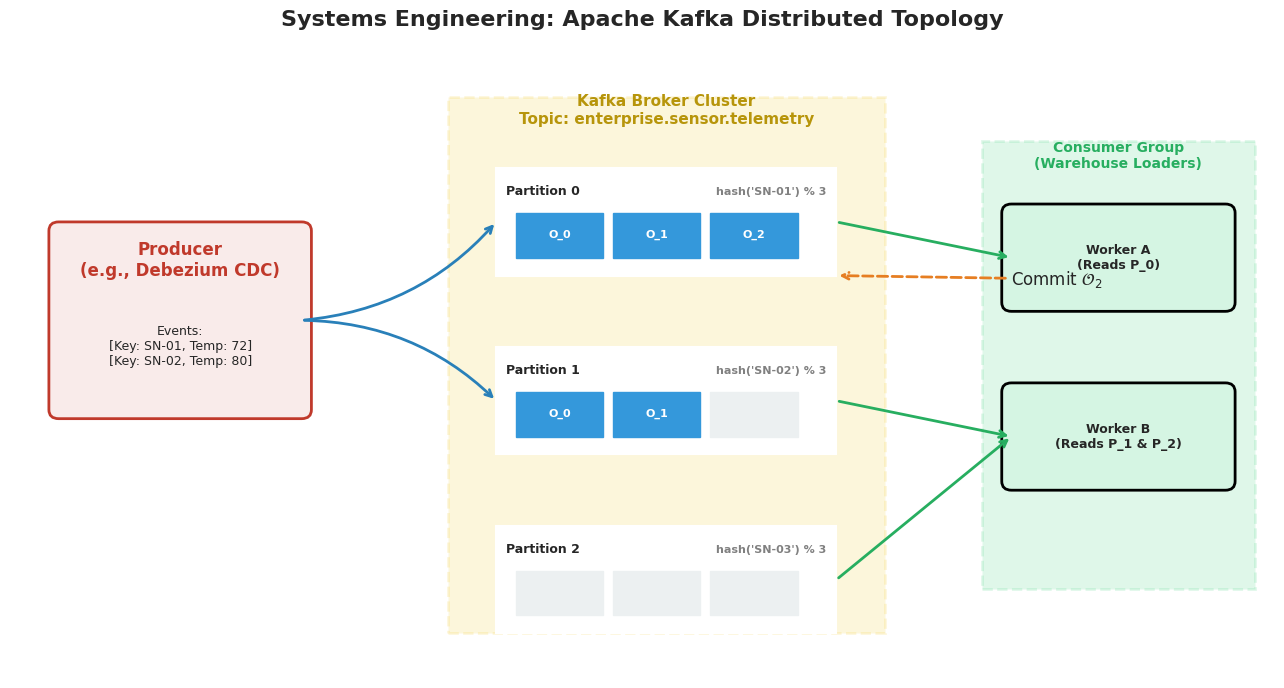

In [4]:
# Visualizing the Kafka Cluster Architecture
fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("Systems Engineering: Apache Kafka Distributed Topology", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Producer Zone
producer_box = patches.FancyBboxPatch((0.5, 3), 2.5, 2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='#c0392b', facecolor='#f9ebea', zorder=3)
ax.add_patch(producer_box)
ax.text(1.75, 4.5, "Producer\n(e.g., Debezium CDC)", ha='center', fontweight='bold', color='#c0392b')
ax.text(1.75, 3.5, "Events:\n[Key: SN-01, Temp: 72]\n[Key: SN-02, Temp: 80]", ha='center', fontsize=9)

# 2. Kafka Cluster Zone (The Broker)
cluster_box = patches.Rectangle((4.5, 0.5), 4.5, 6, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(cluster_box)
ax.text(6.75, 6.2, "Kafka Broker Cluster\nTopic: enterprise.sensor.telemetry", ha='center', fontweight='bold', color='#b7950b', fontsize=11)

# Partitions
partitions = [
    (5, 4.5, "Partition 0", "hash('SN-01') % 3", ["O_0", "O_1", "O_2"]),
    (5, 2.5, "Partition 1", "hash('SN-02') % 3", ["O_0", "O_1", "   "]),
    (5, 0.5, "Partition 2", "hash('SN-03') % 3", ["   ", "   ", "   "])
]

for x, y, title, hash_logic, offsets in partitions:
    # Partition Box
    p_box = patches.Rectangle((x, y), 3.5, 1.2, fill=True, color='white', edgecolor='black', linewidth=1.5)
    ax.add_patch(p_box)
    ax.text(x + 0.1, y + 0.9, title, fontweight='bold', fontsize=9)
    ax.text(x + 3.4, y + 0.9, hash_logic, fontweight='bold', fontsize=8, color='gray', ha='right')
    
    # Offset Slots (The Append-Only Array)
    for i, offset_label in enumerate(offsets):
        slot = patches.Rectangle((x + 0.2 + (i*1.0), y + 0.2), 0.9, 0.5, fill=True, color='#3498db' if offset_label.strip() else '#ecf0f1', edgecolor='black')
        ax.add_patch(slot)
        ax.text(x + 0.65 + (i*1.0), y + 0.45, offset_label, ha='center', va='center', color='white' if offset_label.strip() else 'black', fontweight='bold', fontsize=8)


# 3. Consumer Group Zone
cg_box = patches.Rectangle((10, 1), 2.8, 5, fill=True, color='#2ecc71', alpha=0.15, edgecolor='black', linewidth=2, linestyle='--')
ax.add_patch(cg_box)
ax.text(11.4, 5.7, "Consumer Group\n(Warehouse Loaders)", ha='center', fontweight='bold', color='#27ae60', fontsize=10)

# Consumer Workers
ax.add_patch(patches.FancyBboxPatch((10.3, 4.2), 2.2, 1, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#d5f5e3', zorder=3))
ax.text(11.4, 4.7, "Worker A\n(Reads P_0)", ha='center', va='center', fontweight='bold', fontsize=9)

ax.add_patch(patches.FancyBboxPatch((10.3, 2.2), 2.2, 1, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#d5f5e3', zorder=3))
ax.text(11.4, 2.7, "Worker B\n(Reads P_1 & P_2)", ha='center', va='center', fontweight='bold', fontsize=9)

# 4. Draw Edges (Data Flow & Hashing)
# Produce Flow
ax.annotate("", xy=(5, 5.1), xytext=(3, 4), arrowprops=dict(arrowstyle="->", lw=2, color="#2980b9", connectionstyle="arc3,rad=0.2"))
ax.annotate("", xy=(5, 3.1), xytext=(3, 4), arrowprops=dict(arrowstyle="->", lw=2, color="#2980b9", connectionstyle="arc3,rad=-0.2"))

# Consume Flow
ax.annotate("", xy=(10.3, 4.7), xytext=(8.5, 5.1), arrowprops=dict(arrowstyle="->", lw=2, color="#27ae60"))
ax.annotate("", xy=(10.3, 2.7), xytext=(8.5, 3.1), arrowprops=dict(arrowstyle="->", lw=2, color="#27ae60"))
ax.annotate("", xy=(10.3, 2.7), xytext=(8.5, 1.1), arrowprops=dict(arrowstyle="->", lw=2, color="#27ae60"))

# Offset Commit Flow
ax.annotate("Commit $\\mathcal{O}_2$", xy=(8.5, 4.5), xytext=(10.3, 4.4), arrowprops=dict(arrowstyle="->", lw=2, color="#e67e22", linestyle="dashed"))

plt.xlim(0, 13)
plt.ylim(0, 7)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Apache Kafka like **The Baggage Handling System at an International Airport**:

* **Standard API/Database Link (Passing Bags by Hand)**: A passenger (Producer) hands their bag directly to the airplane pilot (Consumer). If 10,000 passengers show up at once, the pilot is overwhelmed, drops the bags, and the plane cannot take off. The systems are tightly coupled and bottlenecked.
* **Kafka (The Conveyor Belt System)**: The passenger drops their bag onto a massive, high-speed automated conveyor belt (The Kafka Broker).
* **The Partition Hashing**: The passenger's ticket dictates which specific conveyor lane (Partition) the bag goes to. All bags for "Flight 42" always go to Conveyor Lane 1.
* **The Shock Absorber**: The conveyor belt is effectively infinite. The passengers can dump 100,000 bags onto it in one minute. The belt safely holds them in perfect chronological order.
* **The Consumer Group**: The baggage handlers (Consumers) working at the end of the belt pick up the bags at their own safe, sustainable pace. If a baggage handler takes a coffee break (A Python script crashes), the conveyor belt simply pauses that lane. The bags sit safely on the belt until the handler returns, remembers exactly where they left off (The Offset Commit), and resumes loading.



Kafka perfectly decouples the speed of data creation from the speed of data consumption.